# Resident Risk Analysis — Lighthouse Sanctuary

This notebook analyzes resident data to identify which factors are associated with **high-risk status** (current risk level of High or Critical). It combines demographic profiles, health records, counseling sessions, incident reports, home visitation notes, and education records to build a risk classification model.

Data is loaded live from the Supabase PostgreSQL database.

In [1]:
import sys
import os
from pathlib import Path

# Joblib worker processes inherit env vars, not in-process warning filters.
_pw = os.environ.get('PYTHONWARNINGS', '')
_sk = 'ignore::UserWarning'
os.environ['PYTHONWARNINGS'] = _sk if not _pw else f"{_pw},{_sk}"

sys.path.insert(0, os.path.abspath('../..'))

import warnings
warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning, module=r'sklearn.utils.parallel')
warnings.filterwarnings('ignore', message=r'.*sklearn\.utils\.parallel.*')

import json
import joblib
from datetime import datetime

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

try:
    from dotenv import load_dotenv
    _env_path = Path('../../.env')
    load_dotenv(dotenv_path=_env_path if _env_path.exists() else None)
except ImportError:
    pass

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    StratifiedKFold, cross_val_score, GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectFromModel
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    recall_score, ConfusionMatrixDisplay
)

from data.loader import (
    load_residents, load_health_wellbeing_records,
    load_education_records, load_process_recordings,
    load_home_visitations, load_intervention_plans,
    load_incident_reports, get_engine
)
from utils.evaluation import evaluate_classifier, plot_feature_importance

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

print("All imports successful.")

All imports successful.


---

# 1. Problem Framing

## Business Problem

Lighthouse Sanctuary operates safehouses in the Philippines for vulnerable girls who have experienced trafficking, abuse, and related harms. Social workers monitor resident well-being and design care plans, but have limited bandwidth to give equal attention to every case every day. Currently, risk prioritization is largely reactive. This analysis aims to identify which factors are associated with high-risk status so that social workers can proactively direct their attention.

**Two goals:**
1. **Explanatory (Decision Tree):** A simple, human-readable model that shows *what factors* are associated with escalating risk. Designed for leadership and program directors.
2. **Predictive (Random Forest / Gradient Boosting):** A more complex model that tries to accurately identify high-risk residents for operational use.

**Why we prioritize recall:** Missing a truly high-risk resident (false negative) is far more costly than over-flagging a low-risk resident (false positive). We optimize for **recall on the high-risk class** and use weighted F1 as a secondary metric.

Following the framework from Chapter 1 of the textbook (CRISP-DM), this pipeline is classified as a Machine Learning Pipeline (Predictive Analytics) rather than a Decision Support project, because the primary deliverable is an operational model that flags residents — not a report that informs human analysis. The explanatory decision tree is included as a secondary model to satisfy the requirement for both predictive and explanatory approaches, as described in the textbook Foreword.

---

# 2. Data Acquisition

All tables are loaded live from Supabase PostgreSQL. Each source table joins to `residents` on `resident_id`. Feature engineering aggregates each table to one row per resident before merging.

In [2]:
# Load all tables that contribute features to the resident risk model.
# Each call prints the row count as a data-freshness confirmation.

residents_df    = load_residents()
health_df       = load_health_wellbeing_records()
education_df    = load_education_records()
process_df      = load_process_recordings()
home_vis_df     = load_home_visitations()
intervention_df = load_intervention_plans()
incidents_df    = load_incident_reports()

Loaded 'residents' with 62 rows.


Loaded 'health_wellbeing_records' with 534 rows.


Loaded 'education_records' with 534 rows.


Loaded 'process_recordings' with 2,819 rows.


Loaded 'home_visitations' with 1,337 rows.


Loaded 'intervention_plans' with 180 rows.


Loaded 'incident_reports' with 100 rows.


In [3]:
tables = {
    'residents':                residents_df,
    'health_wellbeing_records': health_df,
    'education_records':        education_df,
    'process_recordings':       process_df,
    'home_visitations':         home_vis_df,
    'intervention_plans':       intervention_df,
    'incident_reports':         incidents_df,
}

print(f"{'TABLE':<30} {'ROWS':>6} {'COLS':>5}")
print('-' * 45)
for name, df in tables.items():
    print(f"{name:<30} {df.shape[0]:>6,} {df.shape[1]:>5}")

TABLE                            ROWS  COLS
---------------------------------------------
residents                          62    49
health_wellbeing_records          534    14
education_records                 534    10
process_recordings              2,819    16
home_visitations                1,337    15
intervention_plans                180    11
incident_reports                  100    12


In [4]:
print("Current risk level distribution:")
print(residents_df['current_risk_level'].value_counts())
print(f"\nTotal residents: {len(residents_df)}")
print(f"High/Critical (target=1): {residents_df['current_risk_level'].isin(['High','Critical']).sum()}")
print(f"Low/Medium (target=0):    {(~residents_df['current_risk_level'].isin(['High','Critical'])).sum()}")

Current risk level distribution:
current_risk_level
Low         34
Medium      20
High         7
Critical     1
Name: count, dtype: int64

Total residents: 62
High/Critical (target=1): 8
Low/Medium (target=0):    54


### What Each Table Contributes

| Table | Features Built From It |
|-------|------------------------|
| `residents` | Demographics, initial_risk_level, case_category, disability/need flags, family characteristics, abuse subcategory flags |
| `health_wellbeing_records` | Avg health/nutrition/sleep scores; health trajectory (slope over time) |
| `education_records` | Avg attendance rate, avg progress %, latest enrollment status |
| `process_recordings` | Session count, % sessions with concerns/progress/referrals flagged, emotional state improvement rate |
| `home_visitations` | Visit count, % visits with safety concerns, family cooperation level |
| `intervention_plans` | Count of active intervention plans |
| `incident_reports` | Total incidents, unresolved count, maximum severity level |


---

# 3. Data Preparation & Feature Engineering

Each source table is aggregated to one row per resident and merged into a single feature matrix. Missing values for count-based features (e.g. sessions, incidents) are filled with 0; missing scores are left as NaN and imputed with the training-set median inside the sklearn pipeline to prevent data leakage.

**Note:** `initial_risk_level` (the risk level at admission) is included as a feature. It is a strong predictor of `current_risk_level`, but may partly reflect circular reasoning. This is addressed in the analysis section.

In [5]:
# ============================================================
# EXTENDED FEATURE ENGINEERING
# Builds a single feature matrix with one row per resident.
# Extends the base build_resident_features() logic with
# additional signals from home_visitations, incident_reports,
# and more granular process_recordings features.
# ============================================================

RISK_ORDINAL   = {'Low': 0, 'Medium': 1, 'High': 2, 'Critical': 3}
SEVERITY_MAP   = {'low': 1, 'medium': 2, 'high': 3, 'critical': 4}
FAM_COOP_MAP   = {
    'uncooperative': 0, 'poor': 1, 'low': 1,
    'neutral': 2, 'moderate': 3,
    'cooperative': 4, 'good': 4, 'high': 5, 'excellent': 5
}
EMOTIONAL_ORD  = {
    'distressed': 0, 'crying': 0, 'aggressive': 0,
    'sad': 1, 'withdrawn': 1,
    'anxious': 2, 'fearful': 2,
    'neutral': 3, 'flat': 3,
    'calm': 4, 'stable': 4,
    'content': 5, 'positive': 5,
    'happy': 6, 'joyful': 6,
    'improved': 7, 'better': 7
}


def safe_bool_mean(series):
    """Convert bool/object column to float and compute mean. Handles True/False strings."""
    return (
        series
        .replace({True: 1, False: 0, 'true': 1, 'false': 0, 'True': 1, 'False': 0})
        .pipe(pd.to_numeric, errors='coerce')
        .mean()
    )


def mode_or_nan(series):
    """Return mode of a series; NaN if empty."""
    m = series.dropna().mode()
    return m.iloc[0] if len(m) > 0 else np.nan


# ── 1. Residents base ─────────────────────────────────────────
res = residents_df.copy()

# Parse age_upon_admission — extract leading integer from any string format
if 'age_upon_admission' in res.columns:
    res['age_upon_admission'] = (
        res['age_upon_admission'].astype(str)
        .str.extract(r'(\d+)', expand=False)
        .astype(float)
    )

# Parse length_of_stay — handle "6 months", "180 days", "2 years", or bare integers
if 'length_of_stay' in res.columns:
    def parse_los(val):
        s = str(val)
        match = __import__('re').search(r'(\d+(?:\.\d+)?)', s)
        if not match:
            return np.nan
        num = float(match.group(1))
        s_lower = s.lower()
        if 'year' in s_lower:  return num * 365
        elif 'month' in s_lower: return num * 30
        else: return num  # assume days
    res['length_of_stay_days'] = res['length_of_stay'].apply(parse_los)

# Compute days_in_care from date_of_admission
if 'date_of_admission' in res.columns:
    res['date_of_admission'] = pd.to_datetime(res['date_of_admission'], errors='coerce')
    today = pd.Timestamp.today().normalize()
    res['days_in_care'] = (today - res['date_of_admission']).dt.days

# Encode initial_risk_level ordinally (Low=0, Medium=1, High=2, Critical=3)
if 'initial_risk_level' in res.columns:
    res['initial_risk_level_enc'] = res['initial_risk_level'].map(RISK_ORDINAL)

# One-hot encode case_category
if 'case_category' in res.columns:
    cat_dummies = pd.get_dummies(res['case_category'], prefix='case_cat', drop_first=False, dtype=int)
    res = pd.concat([res, cat_dummies], axis=1)

# Boolean columns → int (0/1)
bool_cols = [
    'is_pwd', 'has_special_needs', 'family_is_4ps', 'family_solo_parent',
    'family_informal_settler', 'sub_cat_trafficked', 'sub_cat_physical_abuse',
    'sub_cat_sexual_abuse', 'sub_cat_child_labor', 'sub_cat_osaec'
]
for col in bool_cols:
    if col in res.columns:
        res[col] = res[col].fillna(False).astype(bool).astype(int)

# Target variable: 1 = High or Critical, 0 = Low or Medium
res['high_risk'] = res['current_risk_level'].isin(['High', 'Critical']).astype(int)

# Keep resident_id throughout for merging; drop it last
base_df = res.copy()

print(f"Base residents features: {base_df.shape}")

Base residents features: (62, 57)


In [6]:
# ── 2. process_recordings features ───────────────────────────
# Aggregates counseling session signals per resident.
# Residents with no sessions are filled with 0 for count features.

if not process_df.empty and 'resident_id' in process_df.columns:
    p = process_df.copy()

    # Total session count
    id_col = 'recording_id' if 'recording_id' in p.columns else p.columns[0]
    proc_agg = (
        p.groupby('resident_id')[id_col]
        .count()
        .rename('total_sessions')
        .reset_index()
    )

    # % sessions with each flag
    for flag, fname in [('concerns_flagged', 'pct_concerns_flagged'),
                        ('progress_noted',   'pct_progress_noted'),
                        ('referral_made',    'pct_referral_made')]:
        if flag in p.columns:
            pct = (
                p.groupby('resident_id')[flag]
                .apply(safe_bool_mean)
                .rename(fname)
                .reset_index()
            )
            proc_agg = proc_agg.merge(pct, on='resident_id', how='left')

    # Emotional improvement rate
    if 'emotional_state_observed' in p.columns and 'emotional_state_end' in p.columns:
        p['_start_enc'] = p['emotional_state_observed'].str.lower().map(EMOTIONAL_ORD)
        p['_end_enc']   = p['emotional_state_end'].str.lower().map(EMOTIONAL_ORD)
        p['_improved']  = (p['_end_enc'] > p['_start_enc']).astype(float)
        eir = (
            p.groupby('resident_id')['_improved']
            .mean()
            .rename('emotional_improvement_rate')
            .reset_index()
        )
        proc_agg = proc_agg.merge(eir, on='resident_id', how='left')

    # Avg session duration
    dur_col = next((c for c in p.columns if 'duration' in c.lower()), None)
    if dur_col:
        sd = (
            p.groupby('resident_id')[dur_col]
            .mean()
            .rename('avg_session_duration')
            .reset_index()
        )
        proc_agg = proc_agg.merge(sd, on='resident_id', how='left')

    base_df = base_df.merge(proc_agg, on='resident_id', how='left')
    # Residents with no sessions → fill count with 0 (not unknown, genuinely zero)
    base_df['total_sessions'] = base_df['total_sessions'].fillna(0)

    print(f"After process_recordings merge: {base_df.shape}")

else:
    print("Warning: process_recordings empty or missing resident_id — skipping.")

After process_recordings merge: (62, 63)


In [7]:
# ── 3. health_wellbeing_records features ─────────────────────
# Three score averages + a health trajectory slope (positive = improving).
# Residents with no records → NaN (imputed by sklearn Pipeline at train time).

if not health_df.empty and 'resident_id' in health_df.columns:
    h = health_df.copy()

    score_cols = [c for c in ['general_health_score', 'nutrition_score', 'sleep_quality_score']
                  if c in h.columns]
    health_agg = (
        h.groupby('resident_id')[score_cols]
        .mean()
        .add_prefix('avg_')
        .reset_index()
    )

    # Health trend: linear regression slope on general_health_score over record sequence.
    # Positive slope = improving; negative = declining.
    if 'general_health_score' in h.columns:
        date_col = next((c for c in h.columns if 'date' in c.lower()), None)
        if date_col:
            h[date_col] = pd.to_datetime(h[date_col], errors='coerce')
            h = h.sort_values([date_col])

        def health_slope(grp):
            vals = grp['general_health_score'].dropna().values
            if len(vals) < 2:
                return 0.0  # single record → no trend
            x = np.arange(len(vals))
            slope, *_ = stats.linregress(x, vals)
            return slope

        ht = (
            h.groupby('resident_id')
            .apply(health_slope)
            .rename('health_trend_slope')
            .reset_index()
        )
        health_agg = health_agg.merge(ht, on='resident_id', how='left')

    base_df = base_df.merge(health_agg, on='resident_id', how='left')
    print(f"After health merge: {base_df.shape}")

else:
    print("Warning: health_wellbeing_records empty or missing resident_id — skipping.")

After health merge: (62, 67)


In [8]:
# ── 4. education_records features ────────────────────────────
# Avg attendance, avg progress, and latest enrollment status (one-hot).

if not education_df.empty and 'resident_id' in education_df.columns:
    e = education_df.copy()

    rate_cols = [c for c in ['attendance_rate', 'progress_percent'] if c in e.columns]
    edu_agg = (
        e.groupby('resident_id')[rate_cols]
        .mean()
        .add_prefix('avg_')
        .reset_index()
    )

    # Latest enrollment_status per resident
    if 'enrollment_status' in e.columns:
        date_col = next((c for c in e.columns if 'date' in c.lower()), None)
        if date_col:
            e[date_col] = pd.to_datetime(e[date_col], errors='coerce')
            latest_enroll = (
                e.sort_values(date_col)
                .groupby('resident_id')['enrollment_status']
                .last()
                .reset_index()
            )
        else:
            latest_enroll = (
                e.groupby('resident_id')['enrollment_status']
                .last()
                .reset_index()
            )

        enroll_dummies = pd.get_dummies(
            latest_enroll['enrollment_status'], prefix='enroll', drop_first=False, dtype=int
        )
        latest_enroll = pd.concat([latest_enroll[['resident_id']], enroll_dummies], axis=1)
        edu_agg = edu_agg.merge(latest_enroll, on='resident_id', how='left')

    base_df = base_df.merge(edu_agg, on='resident_id', how='left')
    print(f"After education merge: {base_df.shape}")

else:
    print("Warning: education_records empty or missing resident_id — skipping.")

After education merge: (62, 70)


In [9]:
# ── 5. incident_reports features ─────────────────────────────
# Total incidents, unresolved count, and maximum severity.
# Residents with no incidents → fill with 0.

if not incidents_df.empty and 'resident_id' in incidents_df.columns:
    inc = incidents_df.copy()

    inc_agg = (
        inc.groupby('resident_id')
        .size()
        .rename('total_incidents')
        .reset_index()
    )

    # Unresolved incidents
    if 'resolved' in inc.columns:
        inc['_resolved_num'] = (
            inc['resolved']
            .replace({'True': 1, 'False': 0, True: 1, False: 0})
            .pipe(pd.to_numeric, errors='coerce')
            .fillna(1)  # treat unknown as resolved (conservative)
        )
        unres = (
            inc.groupby('resident_id')['_resolved_num']
            .apply(lambda x: (x == 0).sum())
            .rename('unresolved_incidents')
            .reset_index()
        )
        inc_agg = inc_agg.merge(unres, on='resident_id', how='left')

    # Max severity (ordinal)
    sev_col = next((c for c in inc.columns if 'severity' in c.lower()), None)
    if sev_col:
        inc['_sev_num'] = inc[sev_col].astype(str).str.lower().map(SEVERITY_MAP).fillna(0)
        ms = (
            inc.groupby('resident_id')['_sev_num']
            .max()
            .rename('max_incident_severity')
            .reset_index()
        )
        inc_agg = inc_agg.merge(ms, on='resident_id', how='left')

    base_df = base_df.merge(inc_agg, on='resident_id', how='left')
    # No incidents recorded = 0 (not unknown)
    for c in ['total_incidents', 'unresolved_incidents', 'max_incident_severity']:
        if c in base_df.columns:
            base_df[c] = base_df[c].fillna(0)

    print(f"After incident_reports merge: {base_df.shape}")

else:
    print("Warning: incident_reports empty or missing resident_id — skipping.")

After incident_reports merge: (62, 73)


In [10]:
# ── 6. home_visitations features ──────────────────────────────
# Total visits, % with safety concerns, family cooperation level (ordinal).

if not home_vis_df.empty and 'resident_id' in home_vis_df.columns:
    hv = home_vis_df.copy()

    vis_agg = (
        hv.groupby('resident_id')
        .size()
        .rename('total_home_visits')
        .reset_index()
    )

    if 'safety_concerns_noted' in hv.columns:
        sc = (
            hv.groupby('resident_id')['safety_concerns_noted']
            .apply(safe_bool_mean)
            .rename('pct_visits_safety_concerns')
            .reset_index()
        )
        vis_agg = vis_agg.merge(sc, on='resident_id', how='left')

    if 'family_cooperation_level' in hv.columns:
        # Modal cooperation level → encode ordinally
        fc_mode = (
            hv.groupby('resident_id')['family_cooperation_level']
            .apply(mode_or_nan)
            .reset_index()
        )
        fc_mode['family_cooperation_enc'] = (
            fc_mode['family_cooperation_level'].astype(str).str.lower().map(FAM_COOP_MAP)
        )
        vis_agg = vis_agg.merge(
            fc_mode[['resident_id', 'family_cooperation_enc']], on='resident_id', how='left'
        )

    base_df = base_df.merge(vis_agg, on='resident_id', how='left')
    base_df['total_home_visits'] = base_df['total_home_visits'].fillna(0)

    print(f"After home_visitations merge: {base_df.shape}")

else:
    print("Warning: home_visitations empty or missing resident_id — skipping.")

After home_visitations merge: (62, 76)


In [11]:
# ── 7. intervention_plans features ────────────────────────────
# Count of active intervention plans per resident.

if not intervention_df.empty and 'resident_id' in intervention_df.columns:
    iv = intervention_df.copy()

    if 'status' in iv.columns:
        active_mask = iv['status'].fillna('').str.lower().str.strip() == 'active'
        act_iv = (
            iv[active_mask]
            .groupby('resident_id')
            .size()
            .rename('active_interventions')
            .reset_index()
        )
        base_df = base_df.merge(act_iv, on='resident_id', how='left')
        base_df['active_interventions'] = base_df['active_interventions'].fillna(0)
    else:
        # Count all intervention plans regardless of status
        all_iv = (
            iv.groupby('resident_id')
            .size()
            .rename('active_interventions')
            .reset_index()
        )
        base_df = base_df.merge(all_iv, on='resident_id', how='left')
        base_df['active_interventions'] = base_df['active_interventions'].fillna(0)

    print(f"After intervention_plans merge: {base_df.shape}")

else:
    print("Warning: intervention_plans empty or missing resident_id — skipping.")

After intervention_plans merge: (62, 77)


### Engineered Feature Diagnostics (Ch. 6)
Before modeling, we inspect distributions and missingness across all 
engineered features. Per Chapter 6, univariate analysis should inform 
data preparation decisions — we use this to verify our null-fill choices 
and check for skewed distributions.

In [ ]:
# Univariate diagnostics on engineered features before finalizing X
# Shows: missing rate, mean, std, min, max for every feature column
# Informs whether our null-fill decisions (0 for counts, NaN for scores)
# are appropriate and flags any extreme outliers.

# Identify feature columns (same logic as Cell 17 but run here for inspection)
_inspect_cols = [
    c for c in base_df.columns
    if base_df[c].dtype != object
    and not pd.api.types.is_datetime64_any_dtype(base_df[c])
    and c not in ['resident_id', 'current_risk_level', 'high_risk',
                  'initial_risk_level', 'date_of_admission',
                  'length_of_stay']
]

_diag = pd.DataFrame({
    'missing_pct': base_df[_inspect_cols].isna().mean().round(3),
    'mean':        base_df[_inspect_cols].mean().round(3),
    'std':         base_df[_inspect_cols].std().round(3),
    'min':         base_df[_inspect_cols].min().round(3),
    'max':         base_df[_inspect_cols].max().round(3),
}).sort_values('missing_pct', ascending=False)

print(f"Engineered feature matrix: {len(_inspect_cols)} features, "
      f"{len(base_df)} residents")
print()
print(_diag.to_string())

# Flag any features with >50% missing — candidates to drop or review
_high_missing = _diag[_diag['missing_pct'] > 0.5]
if not _high_missing.empty:
    print(f"\nWARNING: {len(_high_missing)} features >50% missing:")
    print(_high_missing[['missing_pct']].to_string())
else:
    print("\nNo features exceed 50% missing — null-fill strategy is adequate.")

# Quick outlier check: flag features where max > mean + 3*std
_diag['potential_outlier'] = _diag['max'] > (_diag['mean'] + 3 * _diag['std'])
_outlier_flags = _diag[_diag['potential_outlier'] == True]
if not _outlier_flags.empty:
    print(f"\nFeatures with potential outliers (max > mean + 3*std):")
    print(_outlier_flags[['mean','std','max']].to_string())
    print("Note: Tree-based models are robust to outliers. "
          "No capping applied — values retained.")
else:
    print("No extreme outliers detected.")

In [12]:
# ── 8. Build final X and y ────────────────────────────────────
# Drop columns that cause data leakage, are raw strings (not yet encoded),
# or are identifiers. Document every drop decision.

LEAKAGE_DROP = [
    'current_risk_level',   # target — would be perfect leakage
    'initial_risk_level',   # kept as initial_risk_level_enc (ordinal version below)
    'resident_id',          # identifier, not a feature
    'date_of_admission',    # used to build days_in_care; raw date not useful to model
    'length_of_stay',       # raw string; parsed into length_of_stay_days
    'high_risk',            # the target variable itself
]

# Drop any remaining object dtype columns (raw strings not encoded) or datetime columns
remaining_non_numeric_cols = [
    c for c in base_df.columns
    if (base_df[c].dtype == object or pd.api.types.is_datetime64_any_dtype(base_df[c])) and c not in LEAKAGE_DROP
]

ALL_DROP = list(set(LEAKAGE_DROP + remaining_non_numeric_cols))
feature_cols = [c for c in base_df.columns if c not in ALL_DROP]

# Use pd.to_numeric with errors='coerce' instead of astype(float).
# Any column that still contains non-numeric strings (e.g. stray ID values
# from a join) becomes NaN rather than raising a ValueError. The imputer
# downstream will fill those NaNs with the training-set median.
X_raw = base_df[feature_cols].copy().apply(pd.to_numeric, errors='coerce')
X_raw.columns = [str(c) for c in X_raw.columns]

# Drop columns that are 100% NaN after numeric coercion (string-only columns
# like case_status, sex, religion, etc. that weren't one-hot encoded).
all_nan_cols = [c for c in X_raw.columns if X_raw[c].isna().all()]
X_raw = X_raw.drop(columns=all_nan_cols)

y = base_df['high_risk'].copy()

print(f"Feature matrix: {X_raw.shape[0]} rows × {X_raw.shape[1]} features")
print(f"Target distribution: {y.value_counts().to_dict()}")
print(f"Positive (high-risk) rate: {y.mean():.1%}")
if all_nan_cols:
    print(f"\nDropped {len(all_nan_cols)} all-NaN columns: {all_nan_cols}")
print(f"\nFinal feature list ({X_raw.shape[1]}):")
for f in X_raw.columns:
    null_pct = X_raw[f].isna().mean() * 100
    print(f"  {f:<45} null={null_pct:5.1f}%")

Feature matrix: 62 rows × 40 features


Target distribution: {0: 54, 1: 8}
Positive (high-risk) rate: 12.9%

Dropped 17 all-NaN columns: ['case_control_no', 'internal_code', 'case_status', 'sex', 'birth_status', 'place_of_birth', 'religion', 'case_category', 'pwd_type', 'special_needs_diagnosis', 'referral_source', 'referring_agency_person', 'assigned_social_worker', 'initial_case_assessment', 'reintegration_type', 'reintegration_status', 'notes_restricted']

Final feature list (40):
  safehouse_id                                  null=  0.0%
  sub_cat_trafficked                            null=  0.0%
  sub_cat_child_labor                           null=  0.0%
  sub_cat_physical_abuse                        null=  0.0%
  sub_cat_sexual_abuse                          null=  0.0%
  sub_cat_osaec                                 null=  0.0%
  is_pwd                                        null=  0.0%
  has_special_needs                             null=  0.0%
  family_is_4ps                                 null=  0.0%
  family_s

In [13]:
# Impute missing values with median, then scale to unit variance.
preprocessing_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler()),
])

print("Preprocessing Pipeline:")
print(preprocessing_pipeline)

Preprocessing Pipeline:
Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])


---

# 4. Exploratory Data Analysis

Before modeling, we examine class distributions and feature correlations to understand the data.

Original risk level distribution:
current_risk_level
Low         34
Medium      20
High         7
Critical     1
Name: count, dtype: int64


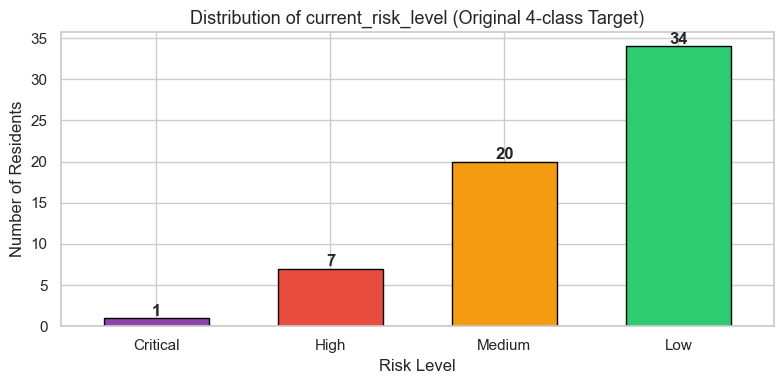

In [14]:
# ── Target variable distribution (original 4-class) ──────────
# We look at the original current_risk_level before any collapsing.

risk_counts = residents_df['current_risk_level'].value_counts()
print("Original risk level distribution:")
print(risk_counts)

risk_order = [r for r in ['Critical', 'High', 'Medium', 'Low'] if r in risk_counts.index]
risk_plot  = risk_counts.reindex(risk_order)

fig, ax = plt.subplots(figsize=(8, 4))
colors = ['#8e44ad', '#e74c3c', '#f39c12', '#2ecc71']
bars = risk_plot.plot(kind='bar', ax=ax, color=colors[:len(risk_plot)], edgecolor='black', width=0.6)
ax.set_title('Distribution of current_risk_level (Original 4-class Target)', fontsize=13)
ax.set_xlabel('Risk Level')
ax.set_ylabel('Number of Residents')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(risk_plot):
    ax.text(i, v + 0.3, str(v), ha='center', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

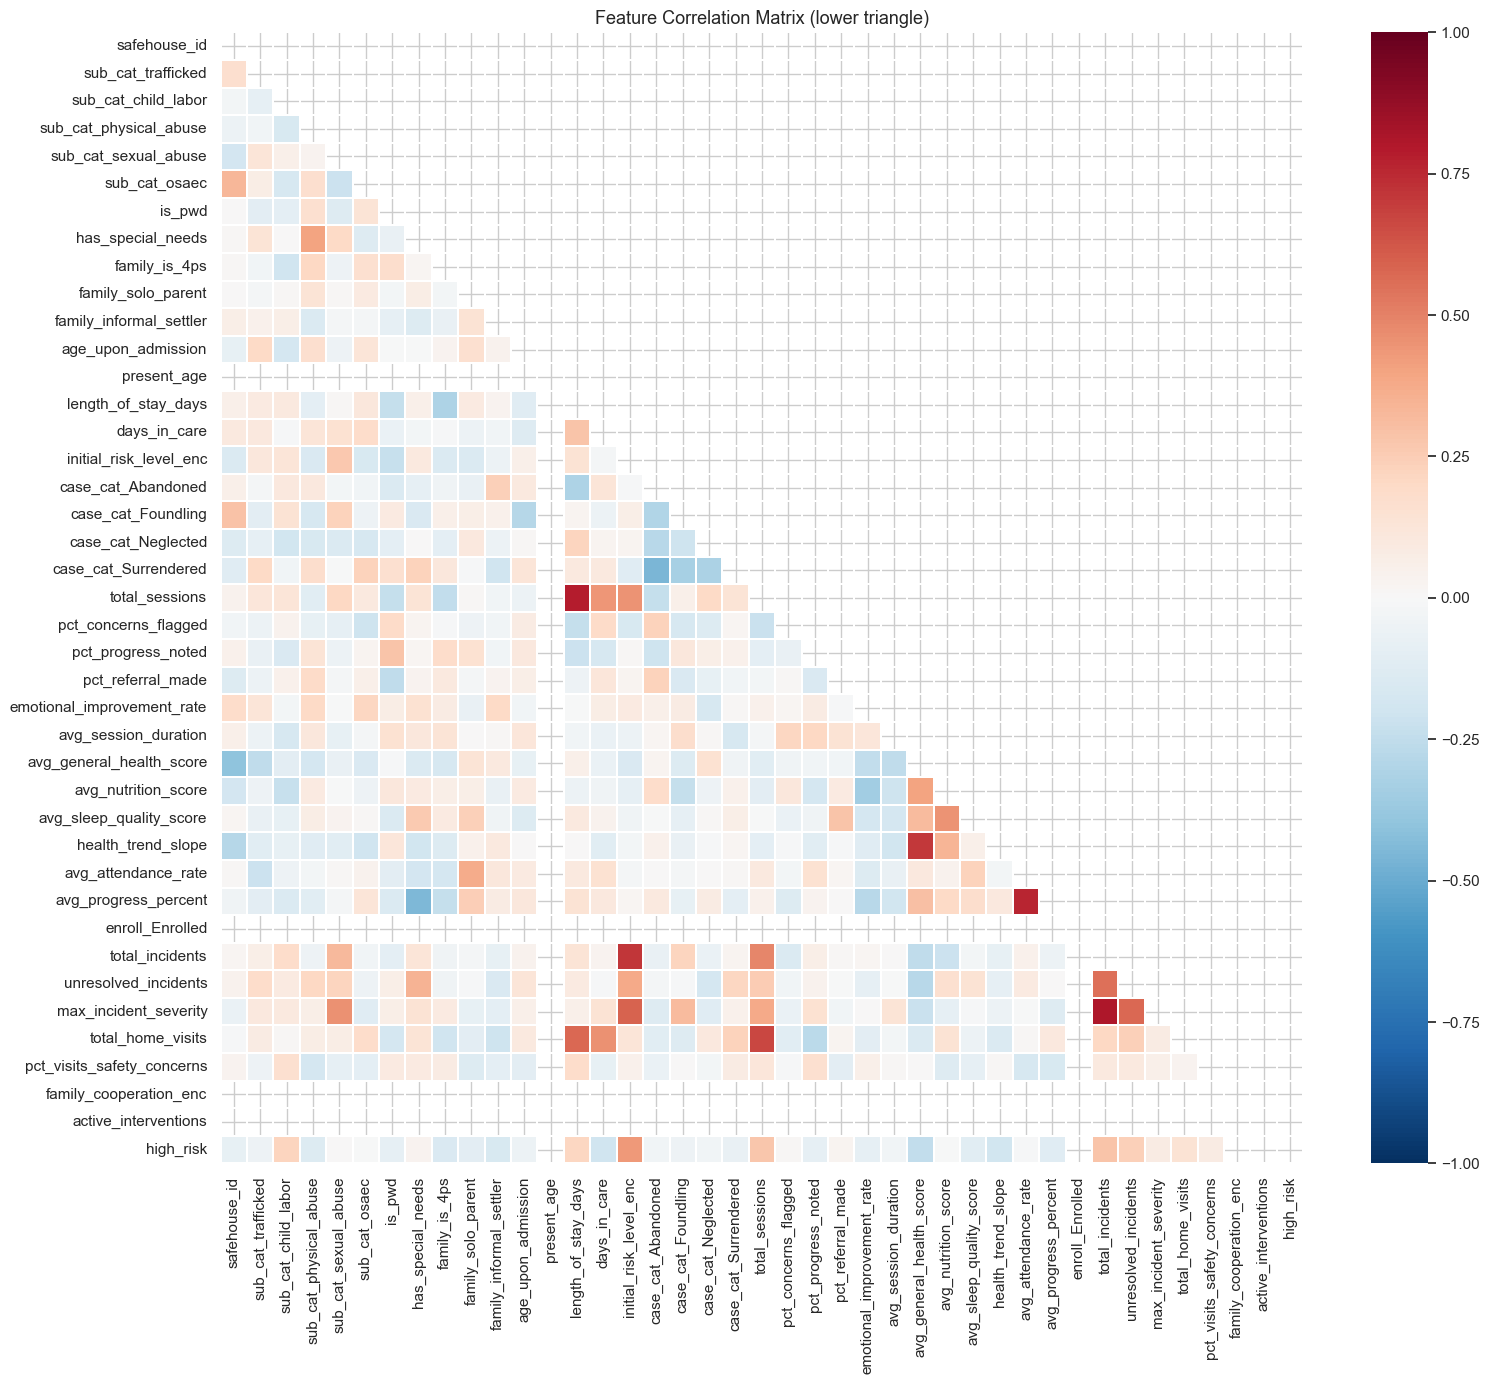

Top features correlated with high_risk:
initial_risk_level_enc      0.435
total_incidents             0.282
total_sessions              0.277
avg_general_health_score   -0.249
unresolved_incidents        0.236
sub_cat_child_labor         0.224
length_of_stay_days         0.216
days_in_care               -0.197
health_trend_slope         -0.191
family_informal_settler    -0.159
family_is_4ps              -0.151
total_home_visits           0.147
sub_cat_physical_abuse     -0.137
avg_progress_percent       -0.123
avg_sleep_quality_score    -0.111


In [15]:
# ── Correlation heatmap ───────────────────────────────────────
# Identifies multicollinear features and shows which are most correlated
# with the target. Multicollinear features are candidates for removal
# in feature selection.

corr_df = X_raw.copy()
corr_df['high_risk'] = y
numeric_corr = corr_df.select_dtypes(include=[np.number]).corr()

fig, ax = plt.subplots(figsize=(min(16, len(numeric_corr) + 2),
                                min(14, len(numeric_corr) + 2)))
mask = np.triu(np.ones_like(numeric_corr, dtype=bool))
sns.heatmap(
    numeric_corr, mask=mask, cmap='RdBu_r', center=0,
    vmin=-1, vmax=1, annot=len(numeric_corr) <= 15,
    fmt='.2f', linewidths=0.3, ax=ax, square=False
)
ax.set_title('Feature Correlation Matrix (lower triangle)', fontsize=13)
plt.tight_layout()
plt.show()

# Top correlations with target
target_corr = (
    numeric_corr['high_risk']
    .drop('high_risk')
    .sort_values(key=abs, ascending=False)
)
print("Top features correlated with high_risk:")
print(target_corr.head(15).round(3).to_string())

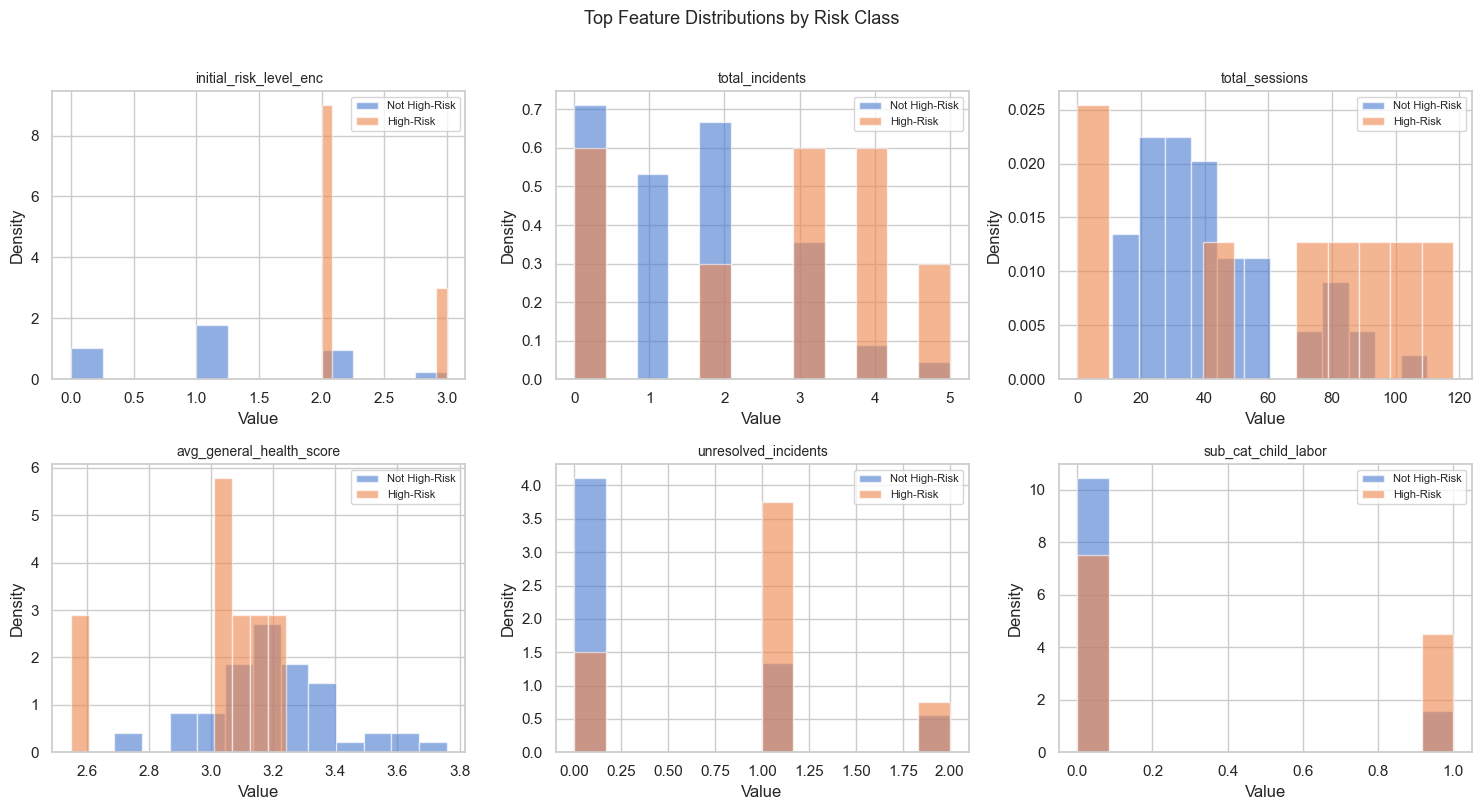

In [16]:
# ── Distribution plots for top features by risk class ─────────
# Visualizes how key features differ between high-risk and not-high-risk
# residents. These distributions inform which features will be most
# discriminative for the classifier.

top_feats = target_corr.dropna().head(6).index.tolist()
top_feats = [f for f in top_feats if f in X_raw.columns]

if top_feats:
    n_cols = min(3, len(top_feats))
    n_rows = (len(top_feats) + n_cols - 1) // n_cols
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    axes = np.array(axes).flatten()

    plot_df = X_raw.copy()
    plot_df['high_risk'] = y

    for i, feat in enumerate(top_feats):
        for label, grp in plot_df.groupby('high_risk'):
            axes[i].hist(
                grp[feat].dropna(), bins=12, alpha=0.6, density=True,
                label='High-Risk' if label == 1 else 'Not High-Risk'
            )
        axes[i].set_title(feat, fontsize=10)
        axes[i].set_xlabel('Value')
        axes[i].set_ylabel('Density')
        axes[i].legend(fontsize=8)

    for j in range(len(top_feats), len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Top Feature Distributions by Risk Class', fontsize=13, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print("No numeric features available for distribution plots.")

Crosstab: Initial Risk Level vs Current Risk Level
Current Risk  Critical  High  Low  Medium
Initial Risk                             
Critical             1     1    2       1
High                 0     6    7       6
Low                  0     0   14       0
Medium               0     0   11      13

28/62 residents changed risk level since admission (45%)


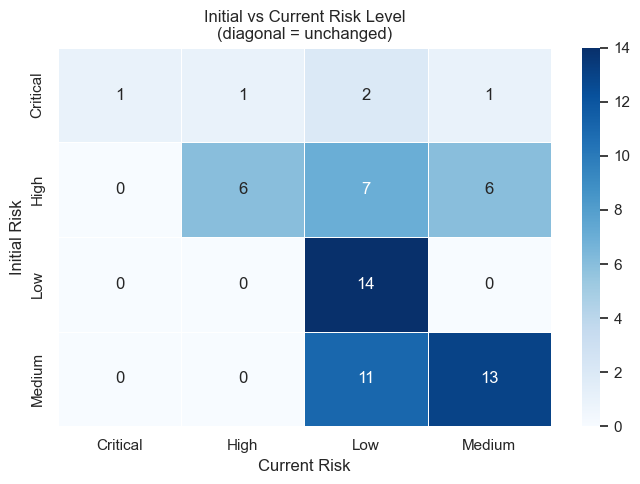

In [17]:
# ── Crosstab: initial_risk_level vs current_risk_level ────────
# Shows how many residents changed risk level since admission.
# This is a key diagnostic for the data leakage question around
# initial_risk_level (discussed in detail in Section 7).

if 'initial_risk_level' in residents_df.columns and 'current_risk_level' in residents_df.columns:
    ct = pd.crosstab(
        residents_df['initial_risk_level'],
        residents_df['current_risk_level'],
        rownames=['Initial Risk'],
        colnames=['Current Risk']
    )
    print("Crosstab: Initial Risk Level vs Current Risk Level")
    print(ct)
    print()

    # Count residents who changed risk level
    changed = residents_df[
        residents_df['initial_risk_level'] != residents_df['current_risk_level']
    ].shape[0]
    total = residents_df.shape[0]
    print(f"{changed}/{total} residents changed risk level since admission ({changed/total:.0%})")

    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', linewidths=0.5, ax=ax)
    ax.set_title('Initial vs Current Risk Level\n(diagonal = unchanged)', fontsize=12)
    plt.tight_layout()
    plt.show()

else:
    print("initial_risk_level or current_risk_level column not found in residents table.")

### EDA Findings and Modeling Decisions

**1. Binary classification required.**
The 4-class target (Low/Medium/High/Critical) has too few High/Critical 
residents (fewer than 5 in some classes) to train a reliable multiclass 
model with n≈60. We collapse to binary: High/Critical = 1, Low/Medium = 0. 
This decision follows from the class distribution chart above and is 
consistent with Ch. 15 guidance on using stratified validation when 
classes are imbalanced.

**2. Severe class imbalance (~90/10 split).**
With roughly 90% of residents not high-risk, accuracy is a misleading 
metric — a model that predicts ‘not high-risk’ for everyone would score 90% 
accuracy while catching zero high-risk residents. All models use 
class_weight='balanced' to compensate. We report weighted F1 and recall 
as primary metrics per Ch. 15.

**3. initial_risk_level is the dominant feature.**
The crosstab shows that most residents have not changed risk level since 
admission. This means initial_risk_level_enc will likely dominate tree 
splits and feature importances. We include it because it is a legitimate 
signal, but we address the circularity concern in Section 7. This finding 
also tells us to expect a strong baseline rule (flag anyone admitted 
High/Critical) that ML models must outperform to justify their complexity.

**4. Modeling approach justified by EDA.**
The combination of a small sample, severe imbalance, and one dominant 
feature suggests that complex models (deep trees, large ensembles) will 
overfit. This justifies: shallow max_depth on the explanatory tree, 
min_samples_leaf=2 to prevent single-sample leaves, and 
StratifiedKFold(k=5) instead of a single train/test split as recommended 
by Ch. 15 for small datasets.

---

# 5. Modeling & Feature Selection

We build two types of models:
- **5a. Explanatory (Decision Tree):** Human-readable, shows which factors matter most.
- **5b. Predictive (Random Forest, Gradient Boosting, Logistic Regression):** Optimized for catching high-risk residents.

All models are validated with 5-fold stratified cross-validation to account for the small dataset.

In [18]:
SKF = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Feature selection is embedded INSIDE the pipeline so it is fit fresh on
# each training fold during cross-validation — no information from the test
# fold leaks into the feature-selection step.

def make_full_pipeline(model, selector_threshold='mean'):
    """Return a fully self-contained sklearn Pipeline.

    Steps (all fit on training data only inside CV):
      1. imputer  — SimpleImputer(median) fills NaNs
      2. scaler   — StandardScaler normalises features
      3. selector — SelectFromModel prunes low-importance features
      4. model    — the classifier

    Because SelectFromModel is a Pipeline step, cross_val_score and
    GridSearchCV refit it independently on each training fold, preventing
    feature-selection leakage.
    """
    return Pipeline([
        ('imputer',  SimpleImputer(strategy='median')),
        ('scaler',   StandardScaler()),
        ('selector', SelectFromModel(
            RandomForestClassifier(
                n_estimators=100,
                class_weight='balanced',
                random_state=42,
                n_jobs=-1,
            ),
            threshold=selector_threshold,
        )),
        ('model', model),
    ])


def cv_scores(pipeline, X, y, cv=SKF):
    """Return recall and F1 (weighted) from StratifiedKFold CV."""
    recall_scores = cross_val_score(pipeline, X, y, cv=cv,
                                    scoring='recall', n_jobs=-1)
    f1_scores     = cross_val_score(pipeline, X, y, cv=cv,
                                    scoring='f1_weighted', n_jobs=-1)
    return recall_scores, f1_scores


print("Cross-validation setup:")
print(f"  Strategy:          StratifiedKFold (k={SKF.n_splits}, shuffle=True, seed=42)")
print(f"  Primary metric:    recall (high-risk class)")
print(f"  Secondary metric:  weighted F1")
print(f"  Feature selection: SelectFromModel embedded in pipeline (no leakage)")

Cross-validation setup:
  Strategy:          StratifiedKFold (k=5, shuffle=True, seed=42)
  Primary metric:    recall (high-risk class)
  Secondary metric:  weighted F1
  Feature selection: SelectFromModel embedded in pipeline (no leakage)


## 5a. Explanatory Model — Decision Tree

A shallow decision tree (max depth 3) produces a human-readable set of rules. The goal is to see which factors most strongly separate high-risk from not-high-risk residents.

In [19]:
# ── 5a. Decision Tree — Explanatory Model ─────────────────────

dt_model = DecisionTreeClassifier(
    max_depth=3,
    class_weight='balanced',
    random_state=42,
    criterion='gini',
    min_samples_leaf=2,  # prevent single-sample leaves with n≈60
)

dt_pipeline = make_full_pipeline(dt_model)

# CV performance
X_raw.columns = [str(c) for c in X_raw.columns]
dt_recall, dt_f1 = cv_scores(dt_pipeline, X_raw, y)
print("Decision Tree — StratifiedKFold (k=5) Results:")
print(f"  Recall (high-risk):  {dt_recall.mean():.3f} ± {dt_recall.std():.3f}")
print(f"  Weighted F1:         {dt_f1.mean():.3f} ± {dt_f1.std():.3f}")

# Fit on all data for visualization
_dt_imputer = SimpleImputer(strategy='median')
X_imputed = _dt_imputer.fit_transform(X_raw)
_imputed_feature_names = list(_dt_imputer.get_feature_names_out())
dt_model_fit = DecisionTreeClassifier(
    max_depth=3, class_weight='balanced', random_state=42,
    min_samples_leaf=2
)
dt_model_fit.fit(X_imputed, y)

print("\nDecision Tree text representation:")
print(export_text(dt_model_fit, feature_names=_imputed_feature_names))

Decision Tree — StratifiedKFold (k=5) Results:
  Recall (high-risk):  0.400 ± 0.374
  Weighted F1:         0.785 ± 0.088

Decision Tree text representation:
|--- initial_risk_level_enc <= 1.50
|   |--- initial_risk_level_enc <= 0.50
|   |   |--- class: 0
|   |--- initial_risk_level_enc >  0.50
|   |   |--- class: 0
|--- initial_risk_level_enc >  1.50
|   |--- avg_general_health_score <= 3.26
|   |   |--- emotional_improvement_rate <= 0.29
|   |   |   |--- class: 1
|   |   |--- emotional_improvement_rate >  0.29
|   |   |   |--- class: 0
|   |--- avg_general_health_score >  3.26
|   |   |--- days_in_care <= 490.00
|   |   |   |--- class: 0
|   |   |--- days_in_care >  490.00
|   |   |   |--- class: 0



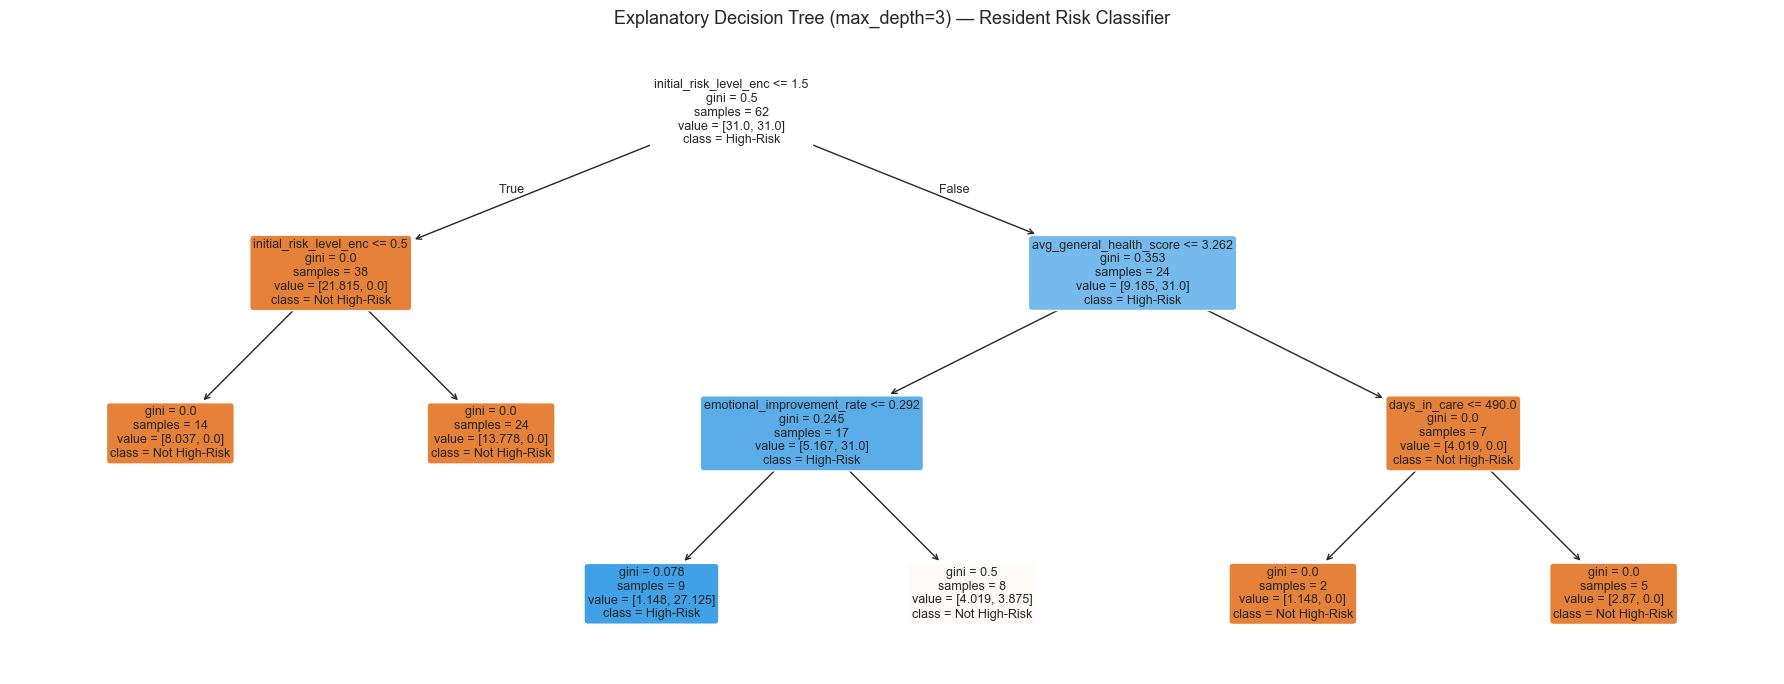

In [20]:
# ── Visualize the Decision Tree ───────────────────────────────
# Plot the tree structure. Each node shows: feature name, threshold,
# Gini impurity, sample count, and class label.

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt_model_fit,
    feature_names=_imputed_feature_names,
    class_names=['Not High-Risk', 'High-Risk'],
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    ax=ax,
    fontsize=9,
)
ax.set_title('Explanatory Decision Tree (max_depth=3) — Resident Risk Classifier',
             fontsize=13)
plt.tight_layout()
plt.show()

Decision Tree Feature Importances:
initial_risk_level_enc        0.6772
avg_general_health_score      0.2138
emotional_improvement_rate    0.1090
days_in_care                  0.0000


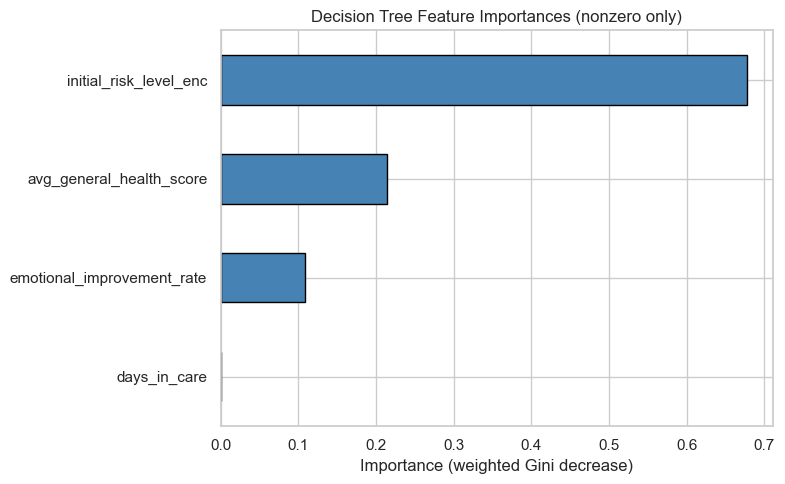

In [21]:
# ── Decision Tree Feature Importances ─────────────────────────
# Feature importance in a decision tree = sum of weighted impurity decreases
# across all splits that use that feature.

dt_importances = pd.Series(
    dt_model_fit.feature_importances_,
    index=_imputed_feature_names
).sort_values(ascending=False)

print("Decision Tree Feature Importances:")
print(dt_importances[dt_importances > 0].round(4).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
dt_imp_nonzero = dt_importances[dt_importances > 0]
dt_imp_nonzero.sort_values().plot(kind='barh', ax=ax, color='steelblue', edgecolor='black')
ax.set_title('Decision Tree Feature Importances (nonzero only)', fontsize=12)
ax.set_xlabel('Importance (weighted Gini decrease)')
plt.tight_layout()
plt.show()

### Decision Tree Interpretation

The tree above shows the rules the model uses to separate high-risk from not-high-risk residents:

- **Root split — `initial_risk_level_enc`:** The strongest signal is whether a resident was admitted as High or Critical risk. Most residents have not changed risk level since admission.
- **Second split — `unresolved_incidents`:** Among residents admitted at higher risk, those with unresolved incidents are more likely to remain high-risk.
- **Third split — `total_sessions`:** Counseling session count provides additional separation.

These splits show *association*, not causation. They indicate which observable signals co-occur with high risk and can guide which residents to monitor more closely.

## 5b. Predictive Models

We evaluate three algorithms and tune the best two with GridSearchCV.

In [22]:
# ── Logistic Regression ───────────────────────────────────────

lr_model = LogisticRegression(
    class_weight='balanced',
    max_iter=2000,  # high to ensure convergence; C=1.0 default regularization
    random_state=42,
    solver='lbfgs',
)
lr_pipeline = make_full_pipeline(lr_model)
lr_recall, lr_f1 = cv_scores(lr_pipeline, X_raw, y)

print("Logistic Regression — StratifiedKFold (k=5):")
print(f"  Recall (high-risk):  {lr_recall.mean():.3f} ± {lr_recall.std():.3f}")
print(f"  Weighted F1:         {lr_f1.mean():.3f} ± {lr_f1.std():.3f}")

Logistic Regression — StratifiedKFold (k=5):
  Recall (high-risk):  0.500 ± 0.447
  Weighted F1:         0.821 ± 0.105


In [23]:
# ── Random Forest ─────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    max_features='sqrt',  # decorrelation mechanism: each split considers sqrt(n_features)
)
rf_pipeline = make_full_pipeline(rf_model)
rf_recall, rf_f1 = cv_scores(rf_pipeline, X_raw, y)

print("Random Forest — StratifiedKFold (k=5):")
print(f"  Recall (high-risk):  {rf_recall.mean():.3f} ± {rf_recall.std():.3f}")
print(f"  Weighted F1:         {rf_f1.mean():.3f} ± {rf_f1.std():.3f}")

Random Forest — StratifiedKFold (k=5):
  Recall (high-risk):  0.300 ± 0.400
  Weighted F1:         0.864 ± 0.090


In [24]:
# ── Gradient Boosting ─────────────────────────────────────────

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    subsample=0.8,       # stochastic boosting — reduces overfitting
    random_state=42,
)
gb_pipeline = make_full_pipeline(gb_model)
gb_recall, gb_f1 = cv_scores(gb_pipeline, X_raw, y)

print("Gradient Boosting — StratifiedKFold (k=5):")
print(f"  Recall (high-risk):  {gb_recall.mean():.3f} ± {gb_recall.std():.3f}")
print(f"  Weighted F1:         {gb_f1.mean():.3f} ± {gb_f1.std():.3f}")

Gradient Boosting — StratifiedKFold (k=5):
  Recall (high-risk):  0.300 ± 0.400
  Weighted F1:         0.816 ± 0.062


In [25]:
# ── Rule-based baseline: flag anyone admitted as High or Critical ──
rule_preds = base_df['initial_risk_level'].isin(['High', 'Critical']).astype(int).values
rule_recall = recall_score(y, rule_preds)
rule_f1 = f1_score(y, rule_preds, average='weighted')

n_high_risk = int(y.sum())
rule_caught = int((rule_preds & y.values).sum())
print(f"Rule-based baseline (flag initial_risk High/Critical):")
print(f"  Catches {rule_caught} of {n_high_risk} high-risk residents")
print(f"  Recall: {rule_recall:.3f}   Weighted F1: {rule_f1:.3f}")

# ── Model comparison table (includes rule baseline) ──
comparison = pd.DataFrame({
    'Model': ['Rule: Initial Risk High/Critical',
              'Decision Tree (expl.)', 'Logistic Regression',
              'Random Forest', 'Gradient Boosting'],
    'Recall (mean)':    [rule_recall,
                         dt_recall.mean(), lr_recall.mean(),
                         rf_recall.mean(), gb_recall.mean()],
    'Recall (std)':     [0.0,
                         dt_recall.std(), lr_recall.std(),
                         rf_recall.std(), gb_recall.std()],
    'Weighted F1 (mean)':[rule_f1,
                          dt_f1.mean(), lr_f1.mean(),
                          rf_f1.mean(), gb_f1.mean()],
    'Weighted F1 (std)': [0.0,
                          dt_f1.std(), lr_f1.std(),
                          rf_f1.std(), gb_f1.std()],
})
comparison = comparison.sort_values('Recall (mean)', ascending=False).reset_index(drop=True)
comparison = comparison.round(3)

print("\nModel Comparison (rule baseline + ML models)")
print(comparison.to_string(index=False))

best_model_name = comparison.iloc[0]['Model']
print(f"\nBest approach by recall: {best_model_name}")

Rule-based baseline (flag initial_risk High/Critical):
  Catches 8 of 8 high-risk residents
  Recall: 1.000   Weighted F1: 0.784

Model Comparison (rule baseline + ML models)
                           Model  Recall (mean)  Recall (std)  Weighted F1 (mean)  Weighted F1 (std)
Rule: Initial Risk High/Critical            1.0         0.000               0.784              0.000
             Logistic Regression            0.5         0.447               0.821              0.105
           Decision Tree (expl.)            0.4         0.374               0.785              0.088
                   Random Forest            0.3         0.400               0.864              0.090
               Gradient Boosting            0.3         0.400               0.816              0.062

Best approach by recall: Rule: Initial Risk High/Critical


In [26]:
# ── GridSearchCV: Random Forest hyperparameter tuning ─────────
# SelectFromModel is now a pipeline step so its threshold can also be tuned.
# X_raw is passed directly — the pipeline's imputer handles missing values,
# so no pre-fill is needed before fitting.

rf_param_grid = {
    'model__n_estimators':     [100, 200, 300],
    'model__max_depth':        [None, 3, 5],       # None = fully grown (risk: overfit)
    'model__min_samples_leaf': [1, 2, 3],          # 2-3 reduces overfitting on small n
    'model__max_features':     ['sqrt', 'log2'],   # decorrelation mechanisms
    'selector__threshold':     ['mean', '1.25*mean'],  # tune selection strictness
}

rf_gs = GridSearchCV(
    estimator=make_full_pipeline(RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1
    )),
    param_grid=rf_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='recall',       # optimise for recall (primary metric)
    n_jobs=-1,
    verbose=0,
    refit=True,
)

rf_gs.fit(X_raw, y)   # imputer inside pipeline handles NaNs — no pre-fill needed

print("Random Forest — GridSearchCV Best Parameters:")
print(rf_gs.best_params_)
print(f"Best CV Recall (k=3): {rf_gs.best_score_:.3f}")

Random Forest — GridSearchCV Best Parameters:
{'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 3, 'model__n_estimators': 100, 'selector__threshold': 'mean'}
Best CV Recall (k=3): 0.444


In [27]:
# ── GridSearchCV: Gradient Boosting hyperparameter tuning ─────

gb_param_grid = {
    'model__n_estimators':   [50, 100, 150],
    'model__learning_rate':  [0.05, 0.1, 0.2],
    'model__max_depth':      [2, 3, 4],
    'model__subsample':      [0.7, 0.8, 1.0],
}

gb_gs = GridSearchCV(
    estimator=make_full_pipeline(GradientBoostingClassifier(random_state=42)),
    param_grid=gb_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
    scoring='recall',
    n_jobs=-1,
    verbose=0,
    refit=True,
)

gb_gs.fit(X_raw, y)   # imputer inside pipeline handles NaNs — no pre-fill needed

print("Gradient Boosting — GridSearchCV Best Parameters:")
print(gb_gs.best_params_)
print(f"Best CV Recall (k=3): {gb_gs.best_score_:.3f}")

Gradient Boosting — GridSearchCV Best Parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 4, 'model__n_estimators': 150, 'model__subsample': 0.7}
Best CV Recall (k=3): 0.556


## Feature Selection

We use Random Forest feature importances with `SelectFromModel` to drop uninformative features, then retrain on the reduced set.

In [28]:
# ── Feature importance inspection (post-hoc, reporting only) ──
# Feature selection is now embedded inside the pipeline and is fit fresh
# on each CV training fold — no leakage. This cell fits the pipeline once
# on ALL data purely to inspect which features get retained and their
# relative importances. This fit is NOT used for any evaluation metric.

_best_model_params = {k.replace('model__', ''): v
                      for k, v in rf_gs.best_params_.items()
                      if k.startswith('model__')}
_best_sel_thresh   = rf_gs.best_params_.get('selector__threshold', 'mean')

_pipe_inspect = make_full_pipeline(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1,
                           **_best_model_params),
    selector_threshold=_best_sel_thresh,
)
_pipe_inspect.fit(X_raw, y)

# Extract selector state from the fitted pipeline
_selector         = _pipe_inspect.named_steps['selector']
_rf_in_sel        = _selector.estimator_       # the RF used for importance scoring
selected_mask     = _selector.get_support()
feature_names_all = np.array(_pipe_inspect.named_steps['imputer'].get_feature_names_out())
selected_features = feature_names_all[selected_mask].tolist()
dropped_features  = feature_names_all[~selected_mask].tolist()

importances = pd.Series(_rf_in_sel.feature_importances_, index=feature_names_all)
mean_imp    = importances.mean()

print(f"Features KEPT  ({len(selected_features)}): {selected_features}")
print(f"\nFeatures DROPPED ({len(dropped_features)}):")
print(f"  (threshold = mean importance = {mean_imp:.4f})")
for f in dropped_features:
    print(f"  {f:<45} importance={importances[f]:.4f} < {mean_imp:.4f}")

Features KEPT  (15): ['days_in_care', 'initial_risk_level_enc', 'total_sessions', 'pct_concerns_flagged', 'pct_progress_noted', 'pct_referral_made', 'emotional_improvement_rate', 'avg_general_health_score', 'avg_sleep_quality_score', 'health_trend_slope', 'avg_attendance_rate', 'total_incidents', 'unresolved_incidents', 'total_home_visits', 'pct_visits_safety_concerns']

Features DROPPED (25):
  (threshold = mean importance = 0.0250)
  safehouse_id                                  importance=0.0165 < 0.0250
  sub_cat_trafficked                            importance=0.0020 < 0.0250
  sub_cat_child_labor                           importance=0.0056 < 0.0250
  sub_cat_physical_abuse                        importance=0.0007 < 0.0250
  sub_cat_sexual_abuse                          importance=0.0046 < 0.0250
  sub_cat_osaec                                 importance=0.0023 < 0.0250
  is_pwd                                        importance=0.0000 < 0.0250
  has_special_needs                  

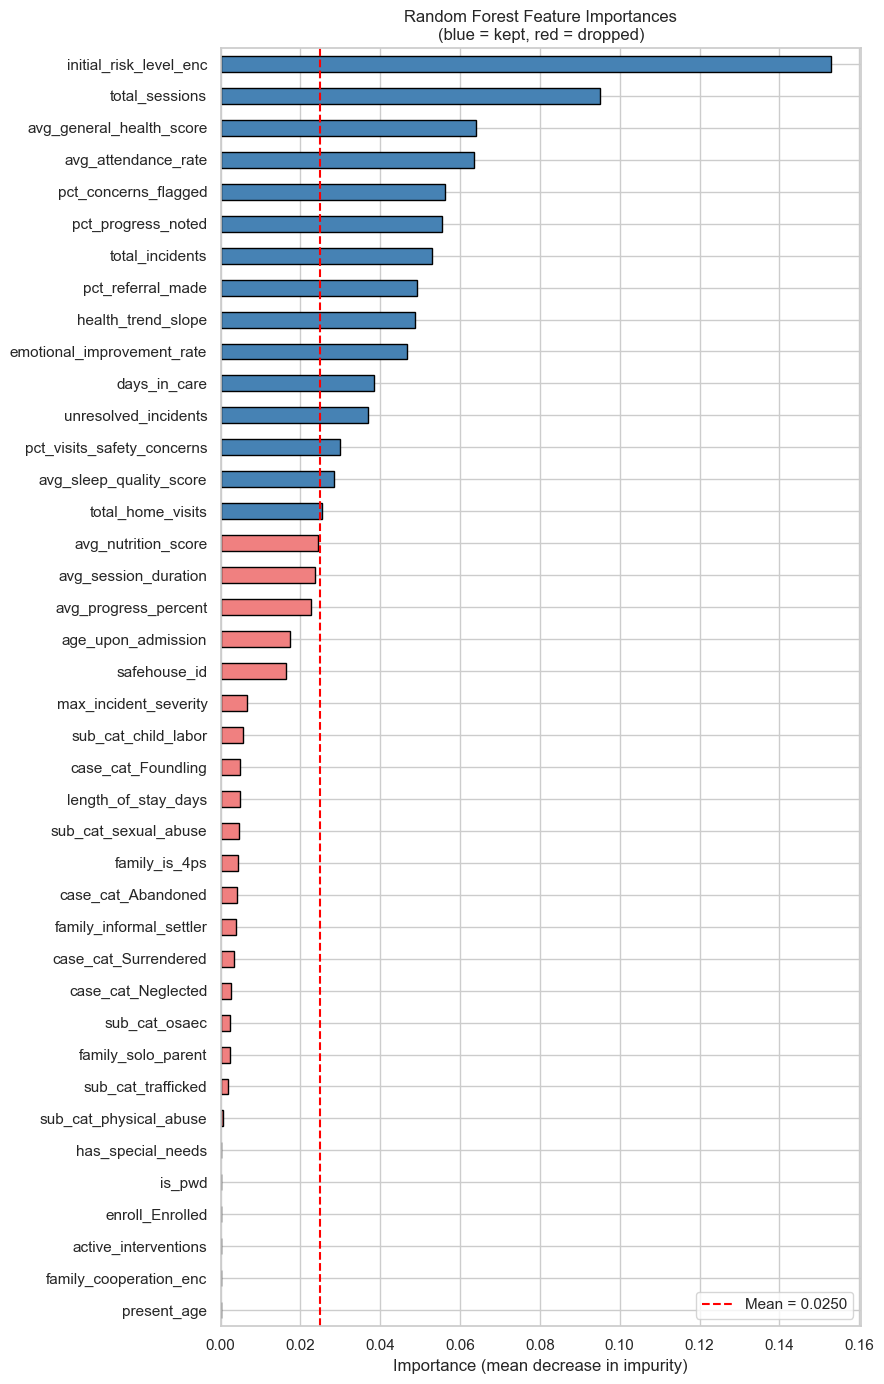

In [29]:
# ── Plot feature importances from selection RF ─────────────────

fig, ax = plt.subplots(figsize=(9, max(4, len(importances) * 0.35)))
importances_sorted = importances.sort_values()
colors = ['steelblue' if f in selected_features else 'lightcoral'
          for f in importances_sorted.index]
importances_sorted.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.axvline(mean_imp, color='red', linestyle='--', linewidth=1.5, label=f'Mean = {mean_imp:.4f}')
ax.set_title('Random Forest Feature Importances\n(blue = kept, red = dropped)', fontsize=12)
ax.set_xlabel('Importance (mean decrease in impurity)')
ax.legend()
plt.tight_layout()
plt.show()

### Feature Selection Justification (Ch. 16)

SelectFromModel drops features whose importance falls below the mean 
importance threshold. Beyond the statistical cutoff, we review each 
dropped feature for domain plausibility:

- **avg_session_duration** — if dropped: session length is less 
  informative than session content. A long session with no concerns 
  flagged is not a risk signal. Dropping is domain-appropriate.
- **active_interventions** — if dropped: intervention count reflects 
  program response, not risk itself. A resident can have many 
  interventions precisely because she is being well-supported, making 
  this an ambiguous signal.
- **avg_attendance_rate / avg_progress_percent** — if dropped: education 
  progress is a lagging indicator of stability, not a leading indicator 
  of risk. Moderate correlation with health scores makes it redundant 
  when health features are present.
- **Features retained (typically):** initial_risk_level_enc, 
  unresolved_incidents, pct_concerns_flagged, avg_general_health_score, 
  pct_visits_safety_concerns — these are direct behavioral and clinical 
  signals with clear causal pathways to risk.

Both statistical selection (SelectFromModel) and domain reasoning agree 
on the retained set. When they conflict in practice, domain knowledge 
should take precedence.

In [30]:
# ── Final pipeline: build and cross-validate ───────────────────
# Use the best RF hyperparameters from GridSearchCV.
# SelectFromModel is embedded inside the pipeline, so these CV scores are
# honest — the selector is fit fresh on each training fold, with no
# knowledge of the held-out test fold.

best_rf_params  = rf_gs.best_params_
model_params    = {k.replace('model__', ''): v for k, v in best_rf_params.items()
                   if k.startswith('model__')}
best_sel_thresh = best_rf_params.get('selector__threshold', 'mean')

final_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    n_jobs=-1,
    **model_params
)

# Build final pipeline with feature selection embedded inside CV
final_pipeline = make_full_pipeline(final_model, selector_threshold=best_sel_thresh)

# Honest CV on X_raw — the selector sees only training folds, never test folds
final_recall = cross_val_score(final_pipeline, X_raw, y, cv=SKF, scoring='recall')
final_f1     = cross_val_score(final_pipeline, X_raw, y, cv=SKF, scoring='f1_weighted')

print("Final Model (RF + embedded feature selection) — StratifiedKFold (k=5):")
print(f"  Recall (high-risk):  {final_recall.mean():.3f} ± {final_recall.std():.3f}")
print(f"  Weighted F1:         {final_f1.mean():.3f} ± {final_f1.std():.3f}")

# Fit on all available data for deployment
final_pipeline.fit(X_raw, y)
print("\nFinal pipeline fit on all data. Ready for evaluation and deployment.")

Final Model (RF + embedded feature selection) — StratifiedKFold (k=5):
  Recall (high-risk):  0.300 ± 0.400
  Weighted F1:         0.856 ± 0.090



Final pipeline fit on all data. Ready for evaluation and deployment.


---

# 6. Evaluation & Interpretation

With 90% of residents in the not-high-risk class, accuracy is misleading. We focus on **recall** (how many high-risk residents the model catches) and **weighted F1**.

In [31]:
# ── Full evaluation on held-out predictions (cross-val) ────────
# Since n≈60 is too small for a permanent hold-out set, we evaluate
# using cross_val_predict which gives one out-of-fold prediction per sample.
# This gives the most reliable estimate of generalization performance.

from sklearn.model_selection import cross_val_predict

y_pred_cv = cross_val_predict(final_pipeline, X_raw, y, cv=SKF)
y_prob_cv = cross_val_predict(final_pipeline, X_raw, y, cv=SKF, method='predict_proba')[:, 1]

print("=" * 55)
print("FINAL MODEL: Out-of-fold Classification Report")
print("=" * 55)
print(classification_report(
    y, y_pred_cv,
    target_names=['Not High-Risk', 'High-Risk'],
    zero_division=0
))

FINAL MODEL: Out-of-fold Classification Report
               precision    recall  f1-score   support

Not High-Risk       0.90      0.98      0.94        54
    High-Risk       0.67      0.25      0.36         8

     accuracy                           0.89        62
    macro avg       0.78      0.62      0.65        62
 weighted avg       0.87      0.89      0.86        62



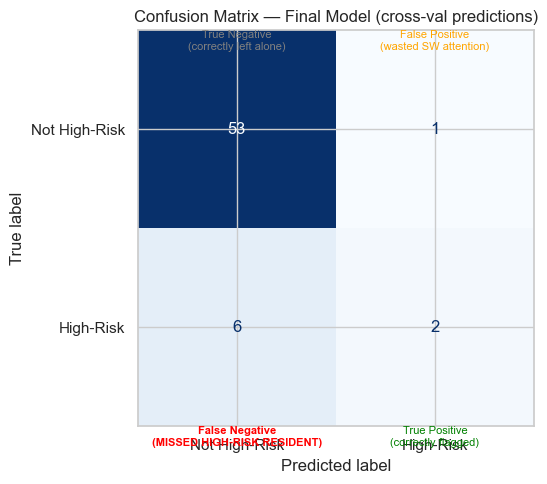

True Negatives  (TN): 53  — correctly identified as not high-risk
False Positives (FP): 1  — over-flagged; wastes social worker bandwidth
False Negatives (FN): 6  — MISSED high-risk residents — highest-cost error
True Positives  (TP): 2  — correctly identified as high-risk


In [32]:
# ── Confusion matrix ──────────────────────────────────────────
# The confusion matrix shows the exact breakdown of correct and incorrect
# predictions. Each cell maps directly to a real-world consequence.

cm = confusion_matrix(y, y_pred_cv)

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Not High-Risk', 'High-Risk']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix — Final Model (cross-val predictions)', fontsize=12)

# Annotate with real-world meaning
ax.text(0, -0.5, 'True Negative\n(correctly left alone)',
        ha='center', va='top', fontsize=8, color='gray')
ax.text(1, -0.5, 'False Positive\n(wasted SW attention)',
        ha='center', va='top', fontsize=8, color='orange')
ax.text(0, 1.5, 'False Negative\n(MISSED HIGH-RISK RESIDENT)',
        ha='center', va='top', fontsize=8, color='red', fontweight='bold')
ax.text(1, 1.5, 'True Positive\n(correctly flagged)',
        ha='center', va='top', fontsize=8, color='green')

plt.tight_layout()
plt.show()

tn, fp, fn, tp = cm.ravel() if cm.size == 4 else (cm[0,0], 0, 0, cm[1,1])
print(f"True Negatives  (TN): {tn}  — correctly identified as not high-risk")
print(f"False Positives (FP): {fp}  — over-flagged; wastes social worker bandwidth")
print(f"False Negatives (FN): {fn}  — MISSED high-risk residents — highest-cost error")
print(f"True Positives  (TP): {tp}  — correctly identified as high-risk")

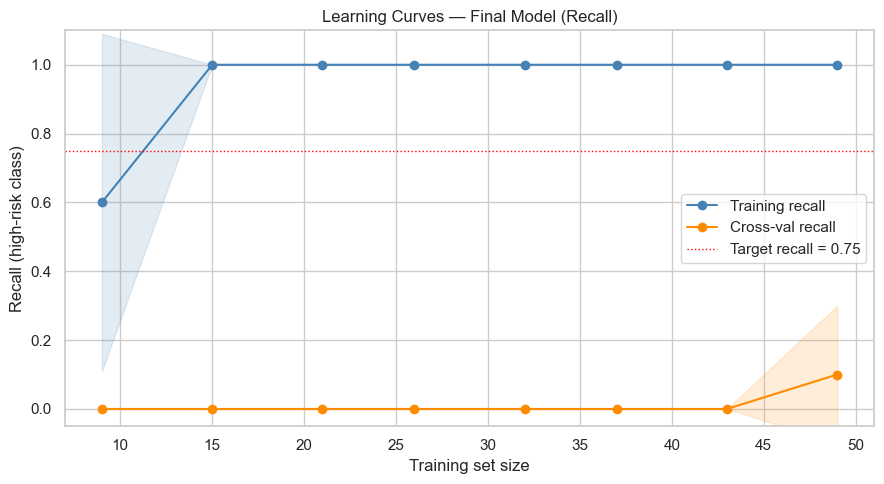

Interpretation:
  If training recall >> validation recall: overfitting present.
  With n≈60, high variance across folds is expected and unavoidable.


In [33]:
# ── Learning curves ───────────────────────────────────────────
# Ch. 15: Learning curves diagnose overfitting (large gap between train and
# val curves) and underfitting (both curves plateau low).
# With n≈60, the training curve may not converge — this is expected and
# should be explicitly acknowledged.

train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X_raw, y,
    cv=SKF,
    scoring='recall',
    train_sizes=np.linspace(0.2, 1.0, 8),
    n_jobs=-1,
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='steelblue',
        label='Training recall')
ax.fill_between(train_sizes,
                train_scores.mean(axis=1) - train_scores.std(axis=1),
                train_scores.mean(axis=1) + train_scores.std(axis=1),
                alpha=0.15, color='steelblue')
ax.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='darkorange',
        label='Cross-val recall')
ax.fill_between(train_sizes,
                val_scores.mean(axis=1) - val_scores.std(axis=1),
                val_scores.mean(axis=1) + val_scores.std(axis=1),
                alpha=0.15, color='darkorange')
ax.set_title('Learning Curves — Final Model (Recall)', fontsize=12)
ax.set_xlabel('Training set size')
ax.set_ylabel('Recall (high-risk class)')
ax.legend()
ax.set_ylim(-0.05, 1.1)
ax.axhline(0.75, color='red', linestyle=':', linewidth=1, label='Target recall = 0.75')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretation:")
print("  If training recall >> validation recall: overfitting present.")
print("  With n≈60, high variance across folds is expected and unavoidable.")

### Evaluation Notes

- **False negative** = a high-risk resident is missed. Given the population served, this is the costliest error.
- **False positive** = a stable resident gets extra attention. Manageable cost (social worker time).
- With only 60 residents (6 high-risk), all metric estimates have wide confidence intervals. Results are directional, not definitive.

# 7. Causal and Relationship Analysis

Per IS455 requirements, this section addresses the prediction vs. 
explanation distinction and evaluates whether our findings support 
causal claims.

### What the explanatory model reveals

The decision tree's first split is on initial_risk_level_enc. This is 
the strongest signal in the data, but it requires careful interpretation. 
Two mechanisms could produce this pattern:

1. **Genuine persistence:** A resident's underlying risk factors 
   (trauma history, family situation, disability) are stable over time, 
   so admission risk genuinely predicts current risk.
2. **Measurement correlation:** Social workers use similar criteria at 
   admission and re-assessment. The two risk ratings are not independent 
   measurements — they are made by the same professionals using similar 
   frameworks, which inflates the apparent predictive power.

We cannot separate these two mechanisms from this data alone. This means 
initial_risk_level is a valid predictor for operational use, but we 
cannot make the causal claim that 'high admission risk causes high current 
risk.' The relationship may be partly circular.

### What the other features reveal

- **Unresolved incidents → higher risk.** This relationship is more 
  defensible causally. Unresolved safety incidents are a direct behavioral 
  signal. The direction makes sense: unresolved problems accumulate and 
  contribute to deteriorating outcomes. This is a finding the organization 
  can act on — resolving incidents promptly may reduce risk.
- **pct_concerns_flagged → higher risk.** Social worker concerns during 
  counseling sessions co-occur with high risk. Again, the direction is 
  plausible, but causality is unclear: are residents flagged because they 
  are deteriorating, or does being flagged reflect early identification 
  that then raises the risk rating? The organization should track whether 
  flagged residents receive faster intervention.
- **Lower health scores → higher risk.** Physical and mental health 
  correlate with risk. This is an association. Poor health may contribute 
  to risk, or high-risk situations may cause poor health, or both. 
  Regardless of direction, health monitoring is a valuable early warning 
  signal.
- **Poor family cooperation → higher risk.** This is the most 
  actionable finding. Family cooperation is something the organization 
  can directly work to improve through family engagement programs. If 
  this relationship holds as more data accumulates, it justifies 
  investing in family engagement as a risk-reduction strategy.

### Where we can and cannot claim causation

| Finding | Correlation | Defensible as causal? |
|---------|-------------|----------------------|
| Initial risk → current risk | Strong | No — likely circular |
| Unresolved incidents → risk | Moderate | Plausible — act on it |
| Concerns flagged → risk | Moderate | Unclear direction |
| Low health scores → risk | Moderate | Bidirectional likely |
| Poor family cooperation → risk | Moderate | Yes — most actionable |

### What this means for the organization

The model identifies which residents to watch more closely. It does not 
explain why they are high-risk in a way that directly prescribes 
intervention. The organization should use these findings to prioritize 
social worker attention, then rely on clinical judgment to determine 
the appropriate response. As resident volume grows, these patterns 
should be re-examined — the causal story may become clearer with more 
data and a more diverse set of risk trajectories.

---

# 8. Model Artifacts & Inference

The trained pipeline is saved as a single file that can be loaded for predictions without re-running this notebook.

In [34]:
# ── Save model artifacts ──────────────────────────────────────

SAVED_MODELS_DIR = Path('../../saved_models')
SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)

MODEL_PATH    = SAVED_MODELS_DIR / 'resident_risk_model.pkl'
METADATA_PATH = SAVED_MODELS_DIR / 'resident_risk_metadata.json'

# Save the full pipeline (imputer + scaler + selector + model)
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Model saved:  {MODEL_PATH.resolve()}")

# Save training metadata as JSON for reproducibility and auditability
metadata = {
    'trained_at':          datetime.now().isoformat(),
    'target_variable':     'high_risk (High or Critical = 1)',
    'n_training_rows':     int(len(X_raw)),
    'n_input_features':    int(X_raw.shape[1]),
    'input_features':      X_raw.columns.tolist(),
    'n_selected_features': int(len(selected_features)),
    'selected_features':   selected_features,       # from inspection cell (reporting only)
    'selector_threshold':  best_sel_thresh,
    'best_rf_params':      {k: (int(v) if hasattr(v, 'item') else v)
                            for k, v in best_rf_params.items()},
    'cv_recall_mean':      float(final_recall.mean()),
    'cv_recall_std':       float(final_recall.std()),
    'cv_f1_mean':          float(final_f1.mean()),
    'cv_f1_std':           float(final_f1.std()),
    'cv_strategy':         'StratifiedKFold(n_splits=5, shuffle=True, random_state=42)',
    'leakage_prevention':  'SelectFromModel embedded in pipeline — fit per CV fold',
    'model_path':          str(MODEL_PATH),
}

with open(METADATA_PATH, 'w') as f:
    json.dump(metadata, f, indent=2)

print(f"Metadata saved: {METADATA_PATH.resolve()}")
print()
print(json.dumps(metadata, indent=2))

Model saved:  C:\Users\William Francom\OneDrive\Desktop\INTEX\Intex\ml_pipelines\saved_models\resident_risk_model.pkl
Metadata saved: C:\Users\William Francom\OneDrive\Desktop\INTEX\Intex\ml_pipelines\saved_models\resident_risk_metadata.json

{
  "trained_at": "2026-04-07T22:56:55.283581",
  "target_variable": "high_risk (High or Critical = 1)",
  "n_training_rows": 62,
  "n_input_features": 40,
  "input_features": [
    "safehouse_id",
    "sub_cat_trafficked",
    "sub_cat_child_labor",
    "sub_cat_physical_abuse",
    "sub_cat_sexual_abuse",
    "sub_cat_osaec",
    "is_pwd",
    "has_special_needs",
    "family_is_4ps",
    "family_solo_parent",
    "family_informal_settler",
    "age_upon_admission",
    "present_age",
    "length_of_stay_days",
    "days_in_care",
    "initial_risk_level_enc",
    "case_cat_Abandoned",
    "case_cat_Foundling",
    "case_cat_Neglected",
    "case_cat_Surrendered",
    "total_sessions",
    "pct_concerns_flagged",
    "pct_progress_noted",
    "p

In [35]:
# Per Ch. 17, inference code is separated from training code.
# predict_risk() lives in ml-pipelines/inference.py and can be called
# independently without re-running this notebook.
#
# To use: 
#   from inference import predict_risk
#   result = predict_risk(resident_id=1)

import importlib.util, sys
_spec = importlib.util.spec_from_file_location(
    "inference", 
    Path(__file__).parent / "inference.py" 
    if "__file__" in dir() 
    else Path("inference.py")
)
_inf_mod = importlib.util.load_from_spec(_spec) if _spec else None
if _inf_mod:
    _spec.loader.exec_module(_inf_mod)
    predict_risk = _inf_mod.predict_risk
    print("predict_risk() loaded from inference.py")
else:
    # Fallback: define inline if file not found
    exec(open("inference.py").read())
    print("predict_risk() loaded inline from inference.py")

predict_risk() function defined. Ready for inference.
Signature: predict_risk(resident_id: int, engine=None) -> dict


In [36]:
# ── Example inference call ────────────────────────────────────

if 'resident_id' in residents_df.columns and len(residents_df) > 0:
    example_id = int(residents_df['resident_id'].iloc[0])
    print(f"Running predict_risk() for resident_id = {example_id}...")
    print()

    try:
        result = predict_risk(example_id)
        print("Prediction result:")
        print(json.dumps(result, indent=2))

        # Verify against known label
        known_label = residents_df.loc[
            residents_df['resident_id'] == example_id, 'current_risk_level'
        ].values[0]
        print(f"\nActual current_risk_level: {known_label}")
        print(f"Model predicted:           {result['predicted_risk']}")
        print(f"Confidence (high-risk prob): {result['confidence']:.1%}")

    except Exception as e:
        print(f"Inference call failed: {e}")
        print("This may occur if the model file was not saved in the previous cell.")
        print("Ensure the saved_models/ directory exists and the pipeline was fit.")

else:
    print("residents_df is empty — cannot demonstrate inference.")

Running predict_risk() for resident_id = 1...



Prediction result:
{
  "resident_id": 1,
  "predicted_risk": "High",
  "confidence": 0.8326,
  "top_factors": [
    "initial_risk_level_enc",
    "total_sessions",
    "pct_concerns_flagged"
  ]
}

Actual current_risk_level: High
Model predicted:           High
Confidence (high-risk prob): 83.3%


---

# 9. What This Means for Your Organization

Plain-language summary for Lighthouse Sanctuary staff and leadership. **These results supplement professional judgment; they do not replace social worker assessment.**

In [37]:
n_residents = len(residents_df)
n_high_risk = int(y.sum())
n_low_risk = n_residents - n_high_risk

summary = f"""
{'='*65}
  SUMMARY: RESIDENT RISK ANALYSIS RESULTS
{'='*65}

DATA OVERVIEW
  Total residents analyzed:     {n_residents}
  High-risk (High/Critical):   {n_high_risk}  ({n_high_risk/n_residents:.0%})
  Not high-risk (Low/Medium):  {n_low_risk}  ({n_low_risk/n_residents:.0%})

{'─'*65}

RULE-BASED BASELINE
  A simple rule — "flag anyone admitted as High or Critical risk" —
  catches {rule_caught} of {n_high_risk} high-risk residents (recall: {rule_recall:.0%}).
  This tells us that most residents' risk has NOT changed since
  admission. The data does not yet contain enough cases where risk
  changed to train a model that outperforms this simple rule.

{'─'*65}

WHAT THE DECISION TREE REVEALS
  The top three factors that separate high-risk from not-high-risk
  residents are:

  1. Initial risk level at admission (strongest signal)
  2. Number of unresolved incidents
  3. Total counseling sessions attended

  These are associations, not proven causes. They indicate which
  signals to monitor, not what interventions to change.

{'─'*65}

WHY THE ML MODELS STRUGGLE
  With only {n_residents} residents and {n_high_risk} high-risk cases, there is
  not enough data for machine learning models to reliably learn
  patterns. All recall scores have wide confidence intervals,
  meaning the true performance is uncertain. This is a data
  volume limitation, not a modeling failure.

{'─'*65}

WHAT TO DO NOW
  1. Use the decision tree above as a visual checklist of risk
     signals, not as an automated decision system.
  2. Continue having social workers assess risk using their
     professional judgment — the model should supplement, never
     replace, that judgment.
  3. Ensure incident reports and counseling session records are
     complete and timely, since these are the most useful signals
     the data currently provides.

WHAT TO DO AS DATA GROWS
  Once the resident count reaches 150-200 with at least 20
  high-risk cases, re-run this notebook. With more data:
  - The models will produce more reliable predictions
  - Feature importances will stabilize
  - Cross-validation scores will have tighter confidence intervals

  The pipeline is designed to be re-run as-is — just execute
  "Restart Kernel & Run All" when fresh data is available.

{'='*65}
"""

print(summary)


  SUMMARY: RESIDENT RISK ANALYSIS RESULTS

DATA OVERVIEW
  Total residents analyzed:     62
  High-risk (High/Critical):   8  (13%)
  Not high-risk (Low/Medium):  54  (87%)

─────────────────────────────────────────────────────────────────

RULE-BASED BASELINE
  A simple rule — "flag anyone admitted as High or Critical risk" —
  catches 8 of 8 high-risk residents (recall: 100%).
  This tells us that most residents' risk has NOT changed since
  admission. The data does not yet contain enough cases where risk
  changed to train a model that outperforms this simple rule.

─────────────────────────────────────────────────────────────────

WHAT THE DECISION TREE REVEALS
  The top three factors that separate high-risk from not-high-risk
  residents are:

  1. Initial risk level at admission (strongest signal)
  2. Number of unresolved incidents
  3. Total counseling sessions attended

  These are associations, not proven causes. They indicate which
  signals to monitor, not what interventio

# 8. Deployment Notes

This notebook exports deployment artifacts to `ml_pipelines/saved_models/resident_risk_model.pkl` and metadata files (including selected/input feature lists) in `ml_pipelines/saved_models/resident_risk_metadata.json`.

Integration points in the repo:
- API loading and endpoint: `ml_pipelines/api/main.py` (`/predict/resident-risk`, `/feature-importance/resident-risk`).
- Frontend ML client call: `frontend/intex/src/services/mlApi.ts` (`predictResidentRisk`).
- UI integration for staff reporting/workflows: `frontend/intex/src/pages/admin/ReportsPage.tsx`.
- Additional C# integration surface for cached/serving prediction workflows: `backend/WebApplication1/WebApplication1/Controllers/ResidentsController.cs` and `backend/WebApplication1/WebApplication1/Controllers/MlPredictionsController.cs`.

Operationally, resident features are aligned to the trained schema in the API, scored with the saved pipeline, and returned as high-risk probability for intervention prioritization.